In [46]:
%pip install -q "numpy<2" tabm rtdl_num_embeddings

Note: you may need to restart the kernel to use updated packages.


In [47]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.utils._pytree as _torch_pytree

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Compatibility patch for packages expecting newer torch pytree API
if not hasattr(_torch_pytree, "register_pytree_node") and hasattr(_torch_pytree, "_register_pytree_node"):
    def _compat_register_pytree_node(cls, flatten_fn, unflatten_fn, *args, **kwargs):
        return _torch_pytree._register_pytree_node(cls, flatten_fn, unflatten_fn)
    _torch_pytree.register_pytree_node = _compat_register_pytree_node

from tabm import TabM

import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# Load data
train_path = "data/train.csv"
test_path = "data/test.csv"
sample_sub_path = "data/sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path)

In [49]:
target_col = "diagnosed_diabetes"

In [50]:

# Split features and target
X = train_df.drop(columns=[target_col])
y = train_df[target_col]
X_test = test_df.copy()

In [51]:
# Detect numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

In [52]:
X = X[num_cols + cat_cols]
X_test = X_test[num_cols + cat_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [53]:
# Preprocessing for TabM
num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
cat_imputer = SimpleImputer(strategy="most_frequent")

# Numeric features
X_num = pd.DataFrame(num_imputer.fit_transform(X[num_cols]), columns=num_cols)
X_num = pd.DataFrame(scaler.fit_transform(X_num), columns=num_cols)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[num_cols]), columns=num_cols)
X_test_num = pd.DataFrame(scaler.transform(X_test_num), columns=num_cols)

# Categorical features (consistent encoding across train+test)
if len(cat_cols) > 0:
    X_cat_raw = pd.DataFrame(cat_imputer.fit_transform(X[cat_cols]), columns=cat_cols).astype(str)
    X_test_cat_raw = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]), columns=cat_cols).astype(str)

    X_all_cat = pd.concat([X_cat_raw, X_test_cat_raw], axis=0, ignore_index=True)
    cat_cardinalities = []
    encoded_cols = []

    for col in cat_cols:
        codes, uniques = pd.factorize(X_all_cat[col], sort=True)
        encoded_cols.append(codes)
        cat_cardinalities.append(len(uniques))

    X_all_cat_enc = np.vstack(encoded_cols).T.astype(np.int64)
    X_cat_enc = X_all_cat_enc[: len(X)]
    X_test_cat_enc = X_all_cat_enc[len(X) :]
else:
    cat_cardinalities = []
    X_cat_enc = np.zeros((len(X), 0), dtype=np.int64)
    X_test_cat_enc = np.zeros((len(X_test), 0), dtype=np.int64)

X_num_np = X_num.to_numpy(dtype=np.float32)
X_test_num_np = X_test_num.to_numpy(dtype=np.float32)
y_np = y.to_numpy(dtype=np.float32)

print("X_num shape:", X_num_np.shape)
print("X_cat shape:", X_cat_enc.shape)
print("X_test_num shape:", X_test_num_np.shape)
print("X_test_cat shape:", X_test_cat_enc.shape)
print("#cat cardinalities:", len(cat_cardinalities))

X_num shape: (700000, 19)
X_cat shape: (700000, 6)
X_test_num shape: (300000, 19)
X_test_cat shape: (300000, 6)
#cat cardinalities: 6


In [54]:
# Official TabM model + training utilities

device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print("Using device:", device)

model_params = {
    "k": 32,
    "n_blocks": 3,
    "d_block": 256,
    "dropout": 0.1,
    "arch_type": "tabm",
}


def build_tabm_model() -> torch.nn.Module:
    return TabM.make(
        n_num_features=X_num_np.shape[1],
        cat_cardinalities=cat_cardinalities,
        d_out=1,
        **model_params,
    ).to(device)


def predict_proba(model, X_num_arr, X_cat_arr, batch_size=4096):
    model.eval()
    all_probs = []

    ds = TensorDataset(
        torch.tensor(X_num_arr, dtype=torch.float32),
        torch.tensor(X_cat_arr, dtype=torch.long),
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for xb_num, xb_cat in dl:
            xb_num = xb_num.to(device)
            xb_cat = xb_cat.to(device)

            logits = model(xb_num, xb_cat).squeeze(-1)      # (B, k)
            probs = torch.sigmoid(logits).mean(dim=1)       # (B,)
            all_probs.extend(probs.detach().cpu().tolist())

    return np.asarray(all_probs, dtype=np.float32)


def train_one_fold(Xn_tr, Xc_tr, y_tr, Xn_val, Xc_val, y_val, max_epochs=80, batch_size=1024, patience=10):
    model = build_tabm_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=3e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    train_ds = TensorDataset(
        torch.tensor(Xn_tr, dtype=torch.float32),
        torch.tensor(Xc_tr, dtype=torch.long),
        torch.tensor(y_tr, dtype=torch.float32),
    )
    # NOTE: shuffle=False avoids a torch+numpy sampler incompatibility in this kernel.
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False)

    best_auc = -np.inf
    best_state = None
    wait = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0

        for xb_num, xb_cat, yb in train_dl:
            xb_num = xb_num.to(device)
            xb_cat = xb_cat.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb_num, xb_cat).squeeze(-1)  # (B, k)
            yb_expanded = yb.unsqueeze(1).expand(-1, logits.shape[1])
            loss = criterion(logits, yb_expanded)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item() * len(yb)

        val_probs = predict_proba(model, Xn_val, Xc_val)
        val_auc = roc_auc_score(y_val, val_probs)
        epoch_loss = running_loss / len(train_ds)

        print(f"Epoch {epoch:03d} | train_loss={epoch_loss:.5f} | val_auc={val_auc:.5f}")

        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return model, best_auc


def train_full_model(Xn, Xc, y_arr, epochs=40, batch_size=1024):
    model = build_tabm_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=3e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    train_ds = TensorDataset(
        torch.tensor(Xn, dtype=torch.float32),
        torch.tensor(Xc, dtype=torch.long),
        torch.tensor(y_arr, dtype=torch.float32),
    )
    # NOTE: shuffle=False avoids a torch+numpy sampler incompatibility in this kernel.
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for xb_num, xb_cat, yb in train_dl:
            xb_num = xb_num.to(device)
            xb_cat = xb_cat.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb_num, xb_cat).squeeze(-1)
            yb_expanded = yb.unsqueeze(1).expand(-1, logits.shape[1])
            loss = criterion(logits, yb_expanded)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item() * len(yb)

        epoch_loss = running_loss / len(train_ds)
        print(f"Full-train epoch {epoch:03d} | loss={epoch_loss:.5f}")

    return model

Using device: mps


In [55]:
# TabM hyperparameter tuning (fast 3-fold -> confirm top configs with 5-fold)

import copy

search_space = [
    {"k": 8,  "n_blocks": 2, "d_block": 96,  "dropout": 0.0, "arch_type": "tabm"},
    {"k": 16, "n_blocks": 2, "d_block": 128, "dropout": 0.1, "arch_type": "tabm"},
    {"k": 24, "n_blocks": 2, "d_block": 128, "dropout": 0.1, "arch_type": "tabm"},
    {"k": 16, "n_blocks": 3, "d_block": 128, "dropout": 0.1, "arch_type": "tabm"},
    {"k": 24, "n_blocks": 3, "d_block": 192, "dropout": 0.1, "arch_type": "tabm"},
    {"k": 32, "n_blocks": 3, "d_block": 192, "dropout": 0.2, "arch_type": "tabm"},
]


def eval_config(cfg, n_splits=3, max_epochs=30, patience=5, batch_size=1024, seed=42):
    global model_params
    model_params.update(cfg)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_num_np, y_np), start=1):
        print(f"\n[{cfg}] | Fold {fold}/{n_splits}")
        _, fold_auc = train_one_fold(
            X_num_np[tr_idx],
            X_cat_enc[tr_idx],
            y_np[tr_idx],
            X_num_np[val_idx],
            X_cat_enc[val_idx],
            y_np[val_idx],
            max_epochs=max_epochs,
            batch_size=batch_size,
            patience=patience,
        )
        fold_scores.append(float(fold_auc))

    return {
        "config": copy.deepcopy(cfg),
        "fold_scores": fold_scores,
        "mean_auc": float(np.mean(fold_scores)),
        "std_auc": float(np.std(fold_scores)),
    }


# ---------- Stage 1: fast screening (3-fold) ----------
all_results = []

for i, cfg in enumerate(search_space, start=1):
    print(f"\n================ Config {i}/{len(search_space)} ================")
    res = eval_config(cfg, n_splits=3, max_epochs=30, patience=5, batch_size=1024, seed=42)
    all_results.append(res)
    print(f"Done: mean_auc={res['mean_auc']:.6f}, std_auc={res['std_auc']:.6f}")

summary_3fold = pd.DataFrame([
    {
        "k": r["config"]["k"],
        "n_blocks": r["config"]["n_blocks"],
        "d_block": r["config"]["d_block"],
        "dropout": r["config"]["dropout"],
        "mean_auc_3fold": r["mean_auc"],
        "std_3fold": r["std_auc"],
    }
    for r in all_results
]).sort_values("mean_auc_3fold", ascending=False).reset_index(drop=True)

print("\n=== Stage 1 (3-fold) leaderboard ===")
print(summary_3fold)

# ---------- Stage 2: confirm top-3 with 5-fold ----------
top_k = min(3, len(summary_3fold))
top_configs = [
    {
        "k": int(summary_3fold.loc[i, "k"]),
        "n_blocks": int(summary_3fold.loc[i, "n_blocks"]),
        "d_block": int(summary_3fold.loc[i, "d_block"]),
        "dropout": float(summary_3fold.loc[i, "dropout"]),
        "arch_type": "tabm",
    }
    for i in range(top_k)
]

confirm_results = []
for rank, cfg in enumerate(top_configs, start=1):
    print(f"\n########## Confirming Top-{rank}: {cfg} with 5-fold ##########")
    res = eval_config(cfg, n_splits=5, max_epochs=50, patience=8, batch_size=1024, seed=42)
    confirm_results.append(res)
    print(f"5-fold mean_auc={res['mean_auc']:.6f}, std_auc={res['std_auc']:.6f}")

summary_5fold = pd.DataFrame([
    {
        "k": r["config"]["k"],
        "n_blocks": r["config"]["n_blocks"],
        "d_block": r["config"]["d_block"],
        "dropout": r["config"]["dropout"],
        "mean_auc_5fold": r["mean_auc"],
        "std_5fold": r["std_auc"],
    }
    for r in confirm_results
]).sort_values("mean_auc_5fold", ascending=False).reset_index(drop=True)

print("\n=== Final leaderboard (5-fold on top configs) ===")
print(summary_5fold)

best_cfg = {
    "k": int(summary_5fold.loc[0, "k"]),
    "n_blocks": int(summary_5fold.loc[0, "n_blocks"]),
    "d_block": int(summary_5fold.loc[0, "d_block"]),
    "dropout": float(summary_5fold.loc[0, "dropout"]),
    "arch_type": "tabm",
}

model_params.update(best_cfg)
print("\nBest config selected and applied to model_params:")
print(model_params)


================ Config 1/6 ================

[{'k': 8, 'n_blocks': 2, 'd_block': 96, 'dropout': 0.0, 'arch_type': 'tabm'}] | Fold 1/3


KeyboardInterrupt: 

In [ ]:
# Train on full training data with selected config from Stage 1

selected_cfg = {
    "k": 16,
    "n_blocks": 3,
    "d_block": 128,
    "dropout": 0.1,
    "arch_type": "tabm",
}
model_params.update(selected_cfg)
print("Using model_params:", model_params)

tabm_model = train_full_model(
    X_num_np,
    X_cat_enc,
    y_np,
    epochs=40,
    batch_size=1024,
)

Using model_params: {'k': 16, 'n_blocks': 3, 'd_block': 128, 'dropout': 0.1, 'arch_type': 'tabm'}
Full-train epoch 001 | loss=0.60692
Full-train epoch 002 | loss=0.60366
Full-train epoch 003 | loss=0.60325
Full-train epoch 004 | loss=0.60298
Full-train epoch 005 | loss=0.60278
Full-train epoch 006 | loss=0.60259
Full-train epoch 007 | loss=0.60248
Full-train epoch 008 | loss=0.60236
Full-train epoch 009 | loss=0.60224
Full-train epoch 010 | loss=0.60214
Full-train epoch 011 | loss=0.60204
Full-train epoch 012 | loss=0.60198
Full-train epoch 013 | loss=0.60187
Full-train epoch 014 | loss=0.60178
Full-train epoch 015 | loss=0.60173
Full-train epoch 016 | loss=0.60169
Full-train epoch 017 | loss=0.60163
Full-train epoch 018 | loss=0.60157
Full-train epoch 019 | loss=0.60154
Full-train epoch 020 | loss=0.60149
Full-train epoch 021 | loss=0.60143
Full-train epoch 022 | loss=0.60141
Full-train epoch 023 | loss=0.60137
Full-train epoch 024 | loss=0.60132
Full-train epoch 025 | loss=0.60130
Fu

In [ ]:
# Predict on test data
test_pred_proba = predict_proba(tabm_model, X_test_num_np, X_test_cat_enc)

# Create submission
submission = sample_sub.copy()
submission.iloc[:, 1] = test_pred_proba

output_path = Path("submissions/tabm_with_id.csv")
submission.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_5650/2262682740.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.59997785 0.60347915 0.6748223  ... 0.6439544  0.6224518  0.5830777 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  submission.iloc[:, 1] = test_pred_proba


Saved: submissions/tabm_with_id.csv


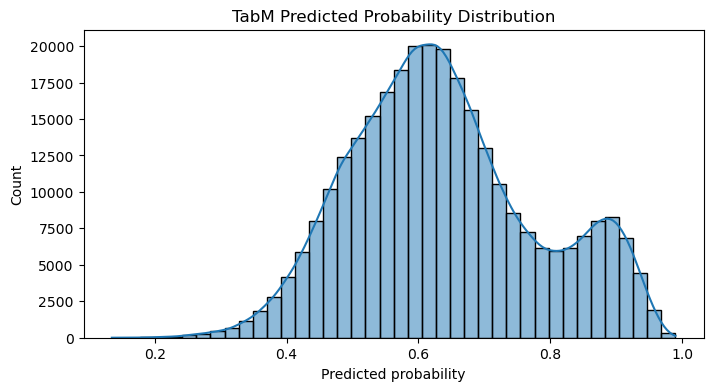

TabM note: use permutation importance / SHAP for post-hoc feature importance.


In [ ]:
# TabM does not provide tree-style feature importances directly.
# Quick sanity check: prediction distribution

plt.figure(figsize=(8, 4))
sns.histplot(test_pred_proba, bins=40, kde=True)
plt.title("TabM Predicted Probability Distribution")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.show()

print("TabM note: use permutation importance / SHAP for post-hoc feature importance.")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture

# Use train OOF probs if possible; if not, use test_pred_proba as a weak proxy
p = np.asarray(test_pred_proba, dtype=float)  # replace with oof_pred if you have it
p = np.clip(p, 1e-6, 1 - 1e-6)

# logit transform (better for Gaussian mixtures than raw [0,1] probs)
z = np.log(p / (1 - p)).reshape(-1, 1)

gmm1 = GaussianMixture(n_components=1, random_state=42).fit(z)
gmm2 = GaussianMixture(n_components=2, random_state=42).fit(z)

bic1, bic2 = gmm1.bic(z), gmm2.bic(z)
print(f"BIC(1 comp)={bic1:.2f}, BIC(2 comp)={bic2:.2f}, delta={bic1-bic2:.2f}")

if bic2 < bic1:
    print("2-component mixture is supported.")
    print("weights:", gmm2.weights_)
    print("means(logit):", gmm2.means_.ravel())
else:
    print("No strong evidence for 2-component mixture.")

BIC(1 comp)=676625.23, BIC(2 comp)=607963.51, delta=68661.72
2-component mixture is supported.
weights: [0.20707826 0.79292174]
means(logit): [1.78440388 0.36028655]


In [ ]:
# Quick smoke test for official TabM (small subset)
smoke_model = build_tabm_model()
smoke_probs = predict_proba(smoke_model, X_num_np[:2048], X_cat_enc[:2048], batch_size=512)
print("Smoke test ok. probs shape:", smoke_probs.shape, "min:", float(smoke_probs.min()), "max:", float(smoke_probs.max()))

Smoke test ok. probs shape: (2048,) min: 0.49243053793907166 max: 0.5017310380935669


In [ ]:
# Optimizer compatibility smoke test
_, quick_auc = train_one_fold(
    X_num_np[:8192],
    X_cat_enc[:8192],
    y_np[:8192],
    X_num_np[8192:10240],
    X_cat_enc[8192:10240],
    y_np[8192:10240],
    max_epochs=1,
    batch_size=512,
    patience=1,
)
print("Quick fold test AUC:", float(quick_auc))

Epoch 001 | train_loss=0.66226 | val_auc=0.65176
Quick fold test AUC: 0.6517638271889701
